# Energy Balance - Empirical
A notebook to check both the atmospheric and surface energy balance to ensure that they match the actual energy balance

In [1]:
import copy
import sys
import os
import re
import inspect
import scipy.optimize

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion, fourier_series
from isca_tools.utils.numerical import get_var_shift, fit_linear_zero_mean, spline_deriv_periodic
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

from jobs.thesis_season.utils import get_empirical_params

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density, moist_static_energy
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_ocean, rho_ocean, Stefan_Boltzmann, R, R_v, g, radius_earth
from isca_tools.utils import numerical, annual_mean
from isca_tools.utils.radiation import get_heat_capacity, frierson_sw_optical_depth, frierson_atmospheric_heating
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer import get_feedback_params, get_heat_cap_lambda_eff, \
    get_heat_cap_lambda_eff_approx
from isca_tools.thesis.surface_energy_budget_2layer2 import get_feedback_params_analytic, combine_olr_adv
from isca_tools.thesis.surface_energy_budget_2layer2 import get_heat_cap_lambda_eff, get_heat_cap_lambda_eff2
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [24]:
# exp_dir = f'tau_sweep/aquaplanet/depth=1/'
# exp_name = 'k=1'
exp_dir = f'thesis_season/depth=5/'         # constrained no WISHE and const RH
exp_name = 'sw_wind_moist'
lat_use = 40
ds_base = utils.load_ds(exp_name, exp_dir, lat_min=lat_use-1, lat_max=lat_use+1, first_month_file=25 if 'tau_sweep' in exp_dir else 121,
                        verbose=True).isel(lat=0)

Computing column temp, sphum, and rh: 100%|██████████| 3/3 [00:18<00:00,  6.22s/it]


In [25]:
ds = utils.process_ds(ds_base)

In [26]:
feedback_params = utils.get_empirical_params(ds)

## Atmospheric Energy Budget
This is closed by definition with advection, but for single column it serves as a sanity check.

In [27]:
def remove_mean(var, mean_dim='time'):
    return var - var.mean(dim=mean_dim)

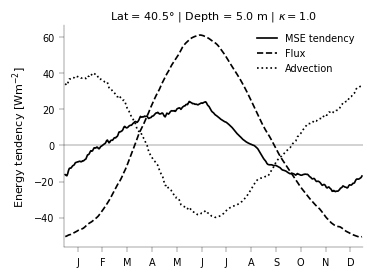

In [32]:
fig, ax = plt.subplots(1, 1, sharex=True)
fig_resize(fig, utils.width['two_col'] * 0.7)
ax.plot(ds.time, remove_mean(ds['mse_tend_atmos']), color='k', label='MSE tendency')
ax.plot(ds.time, remove_mean(ds['flux_atmos']), color='k', label='Flux', linestyle='--')
if 'column' not in exp_dir:
    ax.plot(ds.time, remove_mean(ds['adv_atmos']), color='k', label='Advection', linestyle=':')
else:
    print(f"Max error = {np.abs(ds['adv_atmos']).max():.2f} W/m2")
update_linewidth(fig)
ax.axhline(0, color='k', lw=ax_linewidth)
ax.set_ylabel('Energy tendency [Wm$^{-2}$]')
ax.set_xlim(-1, 360)
ax.set_xticks(*utils.month_ticks)
ax.legend()
ax.set_title(f'Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds.depth:.1f} m | $\kappa = {ds.odp:.1f}$', y=0.99)
plt.show()

### Empirical approximation
Below I compare the empirical approximation for each of the components of the atmospheric energy budget. We see that the approximate empircally fitted computation is not great for the fluxes.

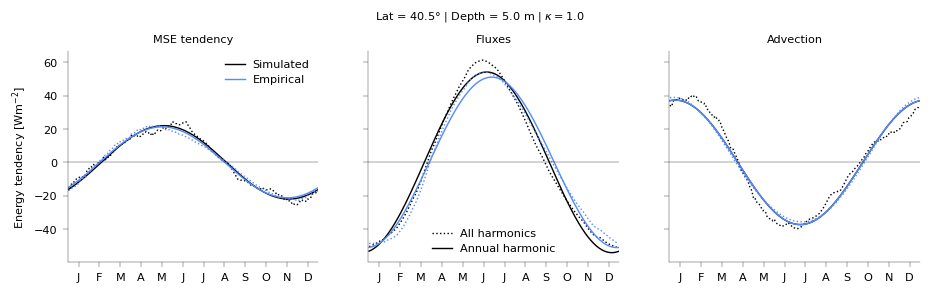

In [31]:
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True)
fig_resize(fig, utils.width['two_col'] * 2)

# MSE tendency - simulated
ax[0].set_title('MSE tendency')
ax[0].plot(ds.time, ds['mse_tend_atmos'], color='k', linestyle=':')
var = get_fourier_fit_xr(ds.time, ds['mse_tend_atmos'], n_harmonics=1, pad_coefs_phase=True)[0]
ax[0].plot(ds.time, var, color='k', label='Simulated')

# MSE tendency - empirical
var = utils.get_approx_mse_tend(ds.temp_atm, feedback_params['coef_amp_col'], feedback_params['coef_phase_col'],
                                feedback_params['mu'], ds['p_integ_calc'].mean(dim='time'), ds.time)
ax[0].plot(ds.time, var, color='C0', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[0].plot(ds.time, var, color='C0', label='Empirical')

# fluxes - simulated
ax[1].set_title('Fluxes')
var = ds['flux_atmos']-ds['flux_atmos'].mean(dim='time')
ax[1].plot(ds.time, var, color='k', linestyle=':', label='All harmonics')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[1].plot(ds.time, var, color='k', label='Annual harmonic')

# fluxes - empirical
var = utils.get_approx_flux_atmos(ds.temp_atm, ds.temp_surf, ds.swdn_toa, ds.sw_abs, feedback_params['lambda_const'],
                                  feedback_params['lambda_a'], feedback_params['B'], feedback_params['lambda_lw1'],
                                  feedback_params['coef_phase_olr'])
ax[1].plot(ds.time, var, color='C0', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[1].plot(ds.time, var, color='C0')

# advection - simulated
ax[2].set_title('Advection')
var = ds['adv_atmos']-ds['adv_atmos'].mean(dim='time')
ax[2].plot(ds.time, var, color='k', linestyle=':', label='All harmonics')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[2].plot(ds.time, var, color='k', label='Annual harmonic')

# advection - empirical
var = utils.get_approx_adv_atmos(ds.temp_atm, feedback_params['lambda_adv'], feedback_params['coef_phase_adv'])
ax[2].plot(ds.time, var, color='C0', linestyle=':')
var = get_fourier_fit_xr(ds.time, var, n_harmonics=1, pad_coefs_phase=True)[0]
ax[2].plot(ds.time, var, color='C0')

update_linewidth(fig)
ax[0].legend()
ax[1].legend()
for i, ax_use in enumerate(ax):
    ax_use.axhline(0, color='k', lw=ax_linewidth)
ax[0].set_xlim(-1, 360)
ax[0].set_xticks(*utils.month_ticks)
ax[0].set_ylabel('Energy tendency [Wm$^{-2}$]')
fig.suptitle(f'Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds.depth:.1f} m | $\kappa = {ds.odp:.1f}$', y=1.03)
update_fontsize(fig)
plt.show()